In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('./sales.csv')
df.head()

,Order Date,Region,Segment,Category,Sub-Category,Sales,Quantity,Profit,Country,City
0,2024-01-13,Central,Consumer,Office Supplies,Binders,1154.89,2,950.39,United States,Los Angeles
1,2024-10-29,South,Consumer,Office Supplies,Binders,197.50,4,195.52,United States,Houston
2,2024-10-14,West,Home Office,Office Supplies,Binders,3266.93,9,513.18,United States,San Diego
3,2024-05-22,East,Consumer,Technology,Laptops,3505.79,6,272.38,United States,New York
4,2024-02-22,East,Corporate,Furniture,Tables,528.75,6,826.33,United States,San Diego


In [12]:
cols = df.columns.tolist()

cols.insert(1, cols.pop(cols.index('Country')))
cols.insert(3, cols.pop(cols.index('City')))

df = df[cols]


In [13]:
df.head()

,Order Date,Country,Region,City,Segment,Category,Sub-Category,Sales,Quantity,Profit
0,2024-01-13,United States,Central,Los Angeles,Consumer,Office Supplies,Binders,1154.89,2,950.39
1,2024-10-29,United States,South,Houston,Consumer,Office Supplies,Binders,197.50,4,195.52
2,2024-10-14,United States,West,San Diego,Home Office,Office Supplies,Binders,3266.93,9,513.18
3,2024-05-22,United States,East,New York,Consumer,Technology,Laptops,3505.79,6,272.38
4,2024-02-22,United States,East,San Diego,Corporate,Furniture,Tables,528.75,6,826.33


In [14]:
df.isnull().sum()

Order Date      0
Country         0
Region          0
City            0
Segment         0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Profit          0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    2000 non-null   object 
 1   Country       2000 non-null   object 
 2   Region        2000 non-null   object 
 3   City          2000 non-null   object 
 4   Segment       2000 non-null   object 
 5   Category      2000 non-null   object 
 6   Sub-Category  2000 non-null   object 
 7   Sales         2000 non-null   float64
 8   Quantity      2000 non-null   int64  
 9   Profit        2000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 156.4+ KB


In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'], yearfirst=True)

In [17]:
df['AOV'] = df['Sales'] / df['Quantity']


In [18]:
df.head()

,Order Date,Country,Region,City,Segment,Category,Sub-Category,Sales,Quantity,Profit,AOV
0,2024-01-13,United States,Central,Los Angeles,Consumer,Office Supplies,Binders,1154.89,2,950.39,577.445000
1,2024-10-29,United States,South,Houston,Consumer,Office Supplies,Binders,197.50,4,195.52,49.375000
2,2024-10-14,United States,West,San Diego,Home Office,Office Supplies,Binders,3266.93,9,513.18,362.992222
3,2024-05-22,United States,East,New York,Consumer,Technology,Laptops,3505.79,6,272.38,584.298333
4,2024-02-22,United States,East,San Diego,Corporate,Furniture,Tables,528.75,6,826.33,88.125000


In [19]:
df['AOV'].dtype

dtype('float64')

In [20]:
df['AOV'] = df['AOV'].astype('int64')

In [21]:
df.head()

,Order Date,Country,Region,City,Segment,Category,Sub-Category,Sales,Quantity,Profit,AOV
0,2024-01-13,United States,Central,Los Angeles,Consumer,Office Supplies,Binders,1154.89,2,950.39,577
1,2024-10-29,United States,South,Houston,Consumer,Office Supplies,Binders,197.50,4,195.52,49
2,2024-10-14,United States,West,San Diego,Home Office,Office Supplies,Binders,3266.93,9,513.18,362
3,2024-05-22,United States,East,New York,Consumer,Technology,Laptops,3505.79,6,272.38,584
4,2024-02-22,United States,East,San Diego,Corporate,Furniture,Tables,528.75,6,826.33,88


In [22]:
df_grp = df.groupby('Segment', as_index=False)['Sales'].sum()
df_grp


,Segment,Sales
0,Consumer,1670640.13
1,Corporate,1745798.23
2,Home Office,1651211.08


<Axes: title={'center': 'Profit by segment'}, xlabel='Segment'>

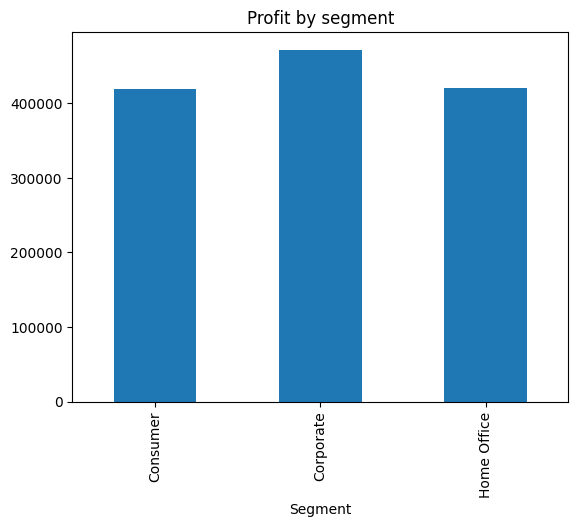

In [23]:
df.groupby('Segment')['Profit'].sum().plot(kind='bar', title="Profit by segment")

<Axes: title={'center': 'Sales By Category'}, xlabel='Category'>

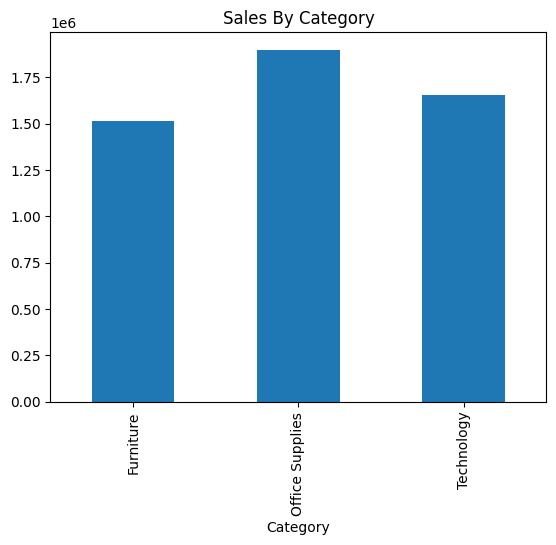

In [48]:
df.groupby('Category')['Sales'].sum().plot(kind='bar', title="Sales By Category")

<Axes: title={'center': 'Sales By Sub-Category'}, xlabel='Sub-Category'>

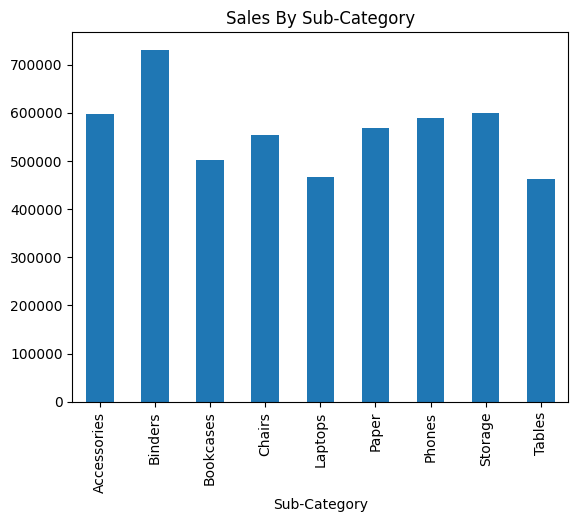

In [24]:
df.groupby('Sub-Category')['Sales'].sum().plot(kind='bar', title="Sales By Sub-Category")

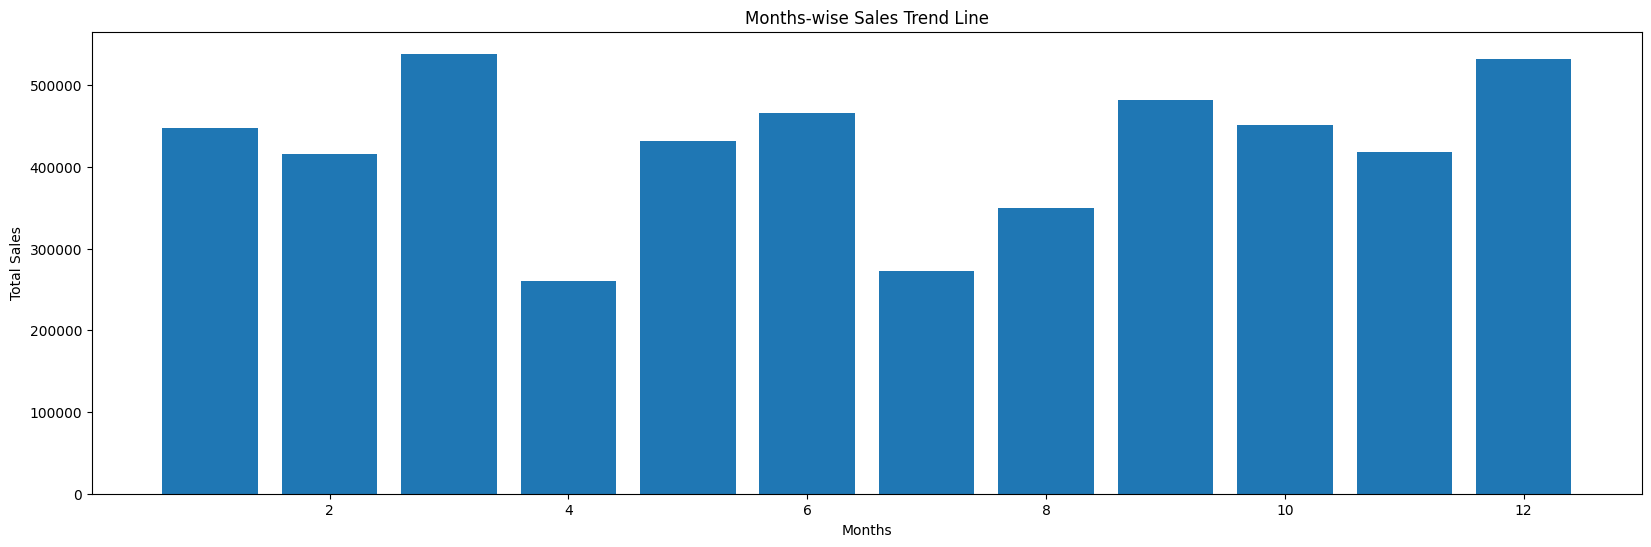

In [ ]:
monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

plt.figure(figsize=(20,6))


plt.bar(monthly_sales.index, monthly_sales.values)

plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.title('Months-wise Sales Trend Line')

plt.show()

In [25]:
df.groupby('City')['Segment'].value_counts()

City          Segment    
Chicago       Corporate      71
              Consumer       68
              Home Office    68
Dallas        Home Office    72
              Corporate      69
              Consumer       57
Houston       Corporate      72
              Home Office    68
              Consumer       63
Los Angeles   Corporate      76
              Home Office    75
              Consumer       59
New York      Consumer       78
              Corporate      68
              Home Office    58
Philadelphia  Home Office    81
              Corporate      78
              Consumer       71
Phoenix       Corporate      59
              Home Office    59
              Consumer       52
San Antonio   Corporate      75
              Consumer       72
              Home Office    60
San Diego     Corporate      75
              Home Office    70
              Consumer       62
San Jose      Corporate      60
              Home Office    55
              Consumer       49
Name: count, d

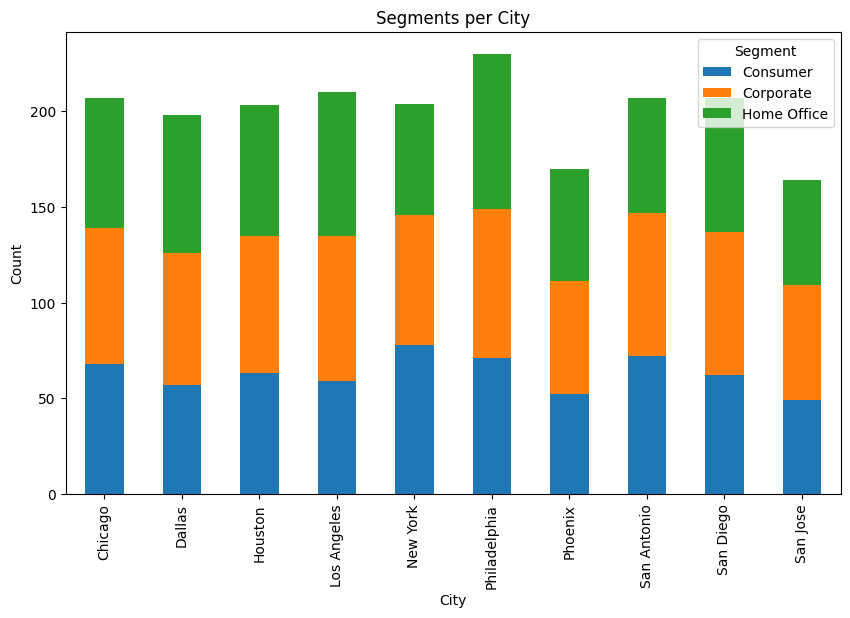

In [69]:
# Using crosstab
city_segment = pd.crosstab(df['City'], df['Segment'])
city_segment.plot(kind='bar', stacked=True, figsize=(10,6), title='Segments per City')
plt.ylabel('Count')
plt.show()


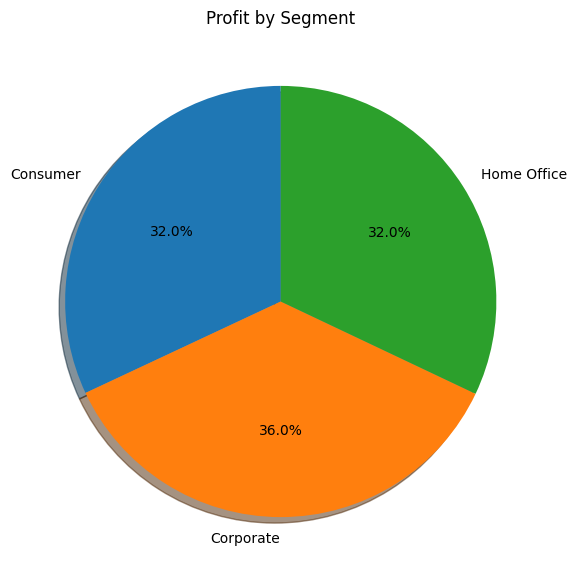

In [26]:
segment_profit = df.groupby("Segment")["Profit"].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    segment_profit,
    labels=segment_profit.index,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
)

plt.title("Profit by Segment")
plt.ylabel("")
plt.show()

In [27]:
df.to_csv("new_sales.csv")